In [1]:
!nvidia-smi

Mon Jul 27 11:08:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install --upgrade diffusers transformers accelerate gradio

In [7]:
!pip uninstall googletrans googletrans-temp httpx httpcore -y

Found existing installation: googletrans 3.1.0a0
Uninstalling googletrans-3.1.0a0:
  Successfully uninstalled googletrans-3.1.0a0
Found existing installation: httpx 0.28.1
Uninstalling httpx-0.28.1:
  Successfully uninstalled httpx-0.28.1
Found existing installation: httpcore 1.0.9
Uninstalling httpcore-1.0.9:
  Successfully uninstalled httpcore-1.0.9


In [11]:
!pip uninstall googletrans -y

In [12]:
!pip install --upgrade diffusers transformers accelerate gradio httpx httpcore -q

In [14]:
from pathlib import Path
import tqdm
import torch
import pandas as pd
import numpy as np
from diffusers import StableDiffusionPipeline
from transformers import pipeline, set_seed
import matplotlib.pyplot as plt
import cv2

print("All libraries imported successfully")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


All libraries imported successfully


In [15]:
def get_translation(text, dest_lang):
  translator = Translator()
  translated_text = translator.translate(text, dest=dest_lang)
  return translated_text.text

In [16]:
class CFG:
  device = "cuda"
  seed = 42

  try:
    generator = torch.Generator(device).manual_seed(seed)
  except Exception as e:
    print(f"Error: {e}")
    device = "cpu"
    generator = torch.Generator(device).manual_seed(seed)

  image_gen_steps = 35
  image_gen_model_id = "stabilityai/stable-diffusion-2-1"
  image_gen_size = (900,900)
  image_gen_guidance_scale = 9
  prompt_gen_model_id = "gpt-omni/mini-omni"
  prompt_dataset_size = 6
  prompt_max_lenghth = 12

In [18]:
import torch
from diffusers import StableDiffusionPipeline

# Configuration
class CFG:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    image_gen_model_id = "runwayml/stable-diffusion-v1-5"
    image_gen_steps = 35
    image_gen_guidance_scale = 9
    image_gen_size = (400, 400)
    generator = torch.Generator(device).manual_seed(42)


# Load model
image_gen_model = StableDiffusionPipeline.from_pretrained(
    CFG.image_gen_model_id,
    torch_dtype=torch.float16 if CFG.device == "cuda" else torch.float32
)

# Move model
image_gen_model = image_gen_model.to(CFG.device)

print("Model loaded successfully!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully!


In [22]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00


In [23]:
from deep_translator import GoogleTranslator

def get_translation(text, dest_lang):
    translated_text = GoogleTranslator(
        source="auto",
        target=dest_lang
    ).translate(text)
    return translated_text

Indian festival Ganesh immersion


  0%|          | 0/35 [00:00<?, ?it/s]

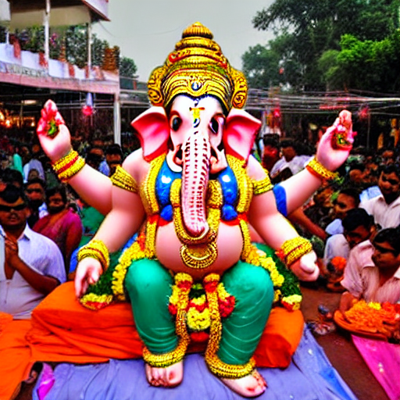

In [24]:
translation = get_translation("भारतीय उत्सव गणेश विसर्जन", "en")
print(translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: Bathukamma festival


  0%|          | 0/35 [00:00<?, ?it/s]

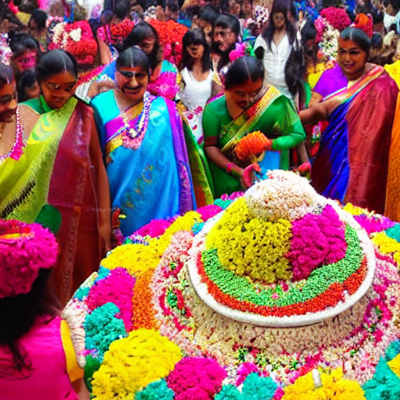

In [28]:
translation = get_translation("బతుకమ్మ పండుగ", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: Pongal festival


  0%|          | 0/35 [00:00<?, ?it/s]

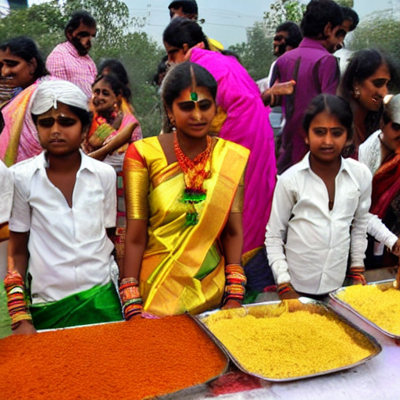

In [29]:
translation = get_translation("பொங்கல் திருவிழா", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: Durga Puja


  0%|          | 0/35 [00:00<?, ?it/s]

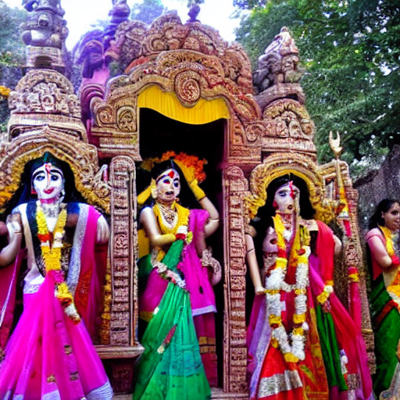

In [30]:
translation = get_translation("দুর্গা পূজা", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: Navratri Garba


  0%|          | 0/35 [00:00<?, ?it/s]

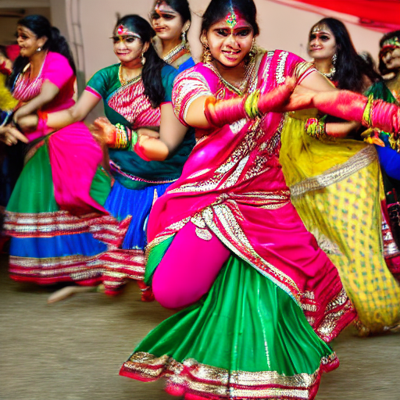

In [31]:
translation = get_translation("નવરાત્રી ગરબા", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: The festival of Vaisakhi


  0%|          | 0/35 [00:00<?, ?it/s]

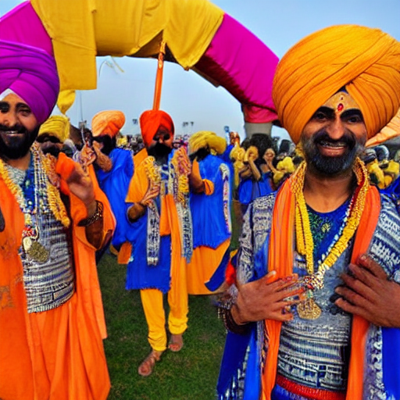

In [32]:
translation = get_translation("ਵੈਸਾਖੀ ਦਾ ਤਿਉਹਾਰ", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image

Translated Prompt: Onam celebration


  0%|          | 0/35 [00:00<?, ?it/s]

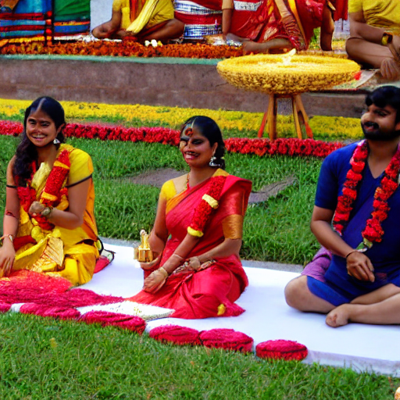

In [33]:
translation = get_translation("ഓണം ആഘോഷം", "en")
print("Translated Prompt:", translation)

image = generate_image(translation, image_gen_model)
image